# FlashFash Shopping Behavior Analysis

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data/raw/shopping.csv")

In [5]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,3475,NaN,Male,Jacket,30.904467,Maine,M,Burnt orange,Fall,4.0,Standard,No,0,Credit Card,NaN
1,3698,21.0,Female,Backpack,31.588259,NaN,L,Turquoise,Winter,2.0,Express,No,1,Credit Card,Monthly
2,2756,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,4.0,Standard,No,0,Credit Card,NaN
3,3340,NaN,Male,Pajamas,33.918834,Nebraska,M,Black,Winter,NaN,Standard,No,2,Credit Card,Bi-Weekly
4,3391,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,NaN,Standard,No,0,Credit Card,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3510 non-null   float64
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Purchase Amount (USD)   3900 non-null   float64
 5   Location                3510 non-null   str    
 6   Size                    3900 non-null   str    
 7   Color                   3900 non-null   str    
 8   Season                  3900 non-null   str    
 9   Review Rating           1431 non-null   float64
 10  Shipping Type           3900 non-null   str    
 11  Promo Code Used         3900 non-null   str    
 12  Previous Purchases      3900 non-null   int64  
 13  Payment Method          3900 non-null   str    
 14  Frequency of Purchases  1560 non-null   str    
dty

In [6]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3510.000000,3900.000000,1431.000000,3900.000000
mean,1950.500000,34.256695,38.708329,3.904962,5.841538
std,1125.977353,10.616340,11.504923,1.105952,5.843695
min,1.000000,18.000000,11.392520,1.000000,0.000000
25%,975.750000,26.000000,29.332617,4.000000,1.000000
50%,1950.500000,33.000000,36.953004,4.000000,4.000000
75%,2925.250000,41.000000,48.739596,5.000000,9.000000
max,3900.000000,75.000000,69.567481,5.000000,20.000000


In [31]:
# pd.pivot_table(df, values = "Purchase Amount (USD)", index = "Gender", columns = "Season", aggfunc= "mean")

#  WHAT ARE THE MOST POPULAR COLORS BY SEASON?

In [53]:

# color_season = df.groupby(['Season', 'Color']).count()

color_counts = df.groupby(["Season", "Color"]).size().reset_index(name="Count")

# used ai to figure out how to show only the top colors for each season
top_color_each_season = color_counts.loc[
    color_counts.groupby("Season")["Count"].idxmax()
]

top_color_each_season

# color_season


,Season,Color,Count
4,Fall,Brown,117
18,Spring,Baby blue,83
41,Summer,Lavender,120
53,Winter,Black,155


# The most popular colors vary by season. In Fall, brown is the most common color, which aligns with typical seasonal trends. In Spring, lighter colors like baby blue are more popular, while Summer shows a preference for colors like lavender. In Winter, black is the most popular color, suggesting customers tend to choose darker tones during colder seasons. Overall, color preferences seem to change with the season, reflecting common fashion patterns.

In [45]:
# df.groupby('Gender')[['Purchase Amount (USD)', 'Review Rating']].mean() #columns are numerical, rows are categorical, that's why can can groupby them.

In [43]:
# pd.pivot_table(df, values = "Purchase Amount (USD)", index = "Gender", columns = "Season", aggfunc= "mean")

#  WHICH AGE GROUP MAKES THE LARGEST PURCHASE?

In [ ]:
# df.groupby('Age')['Purchase Amount (USD)'].max()

df['age_group'] = pd.cut( df['Age'], bins=[0, 18, 30, 50, 100], labels=['Child', 'Young Adult', 'Adult', 'Senior'] )



In [21]:
df

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Shipping Type,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,age_group
0,3475,NaN,Male,Jacket,30.904467,Maine,M,Burnt orange,Fall,4.0,Standard,No,0,Credit Card,NaN,NaN
1,3698,21.0,Female,Backpack,31.588259,NaN,L,Turquoise,Winter,2.0,Express,No,1,Credit Card,Monthly,Young Adult
2,2756,31.0,Male,Leggings,24.231704,Nevada,M,Terra cotta,Winter,4.0,Standard,No,0,Credit Card,NaN,Adult
3,3340,NaN,Male,Pajamas,33.918834,Nebraska,M,Black,Winter,NaN,Standard,No,2,Credit Card,Bi-Weekly,NaN
4,3391,38.0,Male,Sunglasses,36.545487,Oregon,S,Aubergine,Summer,NaN,Standard,No,0,Credit Card,NaN,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,147,43.0,Female,Sunglasses,61.610602,Colorado,S,Burnt orange,Fall,NaN,2-Day Shipping,Yes,7,Venmo,NaN,Adult
3896,1472,37.0,Male,Pajamas,44.600556,Alaska,S,Aubergine,Winter,4.0,2-Day Shipping,Yes,20,Venmo,NaN,Adult
3897,1069,NaN,Female,Handbag,41.781965,Wyoming,M,Fuchsia,Summer,NaN,Standard,Yes,13,Venmo,NaN,NaN
3898,1171,39.0,Male,Hoodie,45.343778,Illinois,S,Brick red,Fall,NaN,2-Day Shipping,Yes,3,Venmo,NaN,Adult


In [23]:
df.groupby('age_group')['Purchase Amount (USD)'].mean()

age_group
Child          39.182301
Young Adult    38.545002
Adult          38.760374
Senior         39.288905
Name: Purchase Amount (USD), dtype: float64

# Seniors have the highest average purchase amount at about $39.29, while young adults have the lowest at about $38.55. However, the differences between age groups are minimal, indicating that age does not significantly affect spending behavior.

# WHICH SHIPPING TYPE IS USED MOST OFTEN?

In [ ]:
df['Shipping Type'].value_counts()

Shipping Type
Standard          2162
2-Day Shipping    1173
Next Day Air       284
Express            279
Store Pickup         2
Name: count, dtype: int64

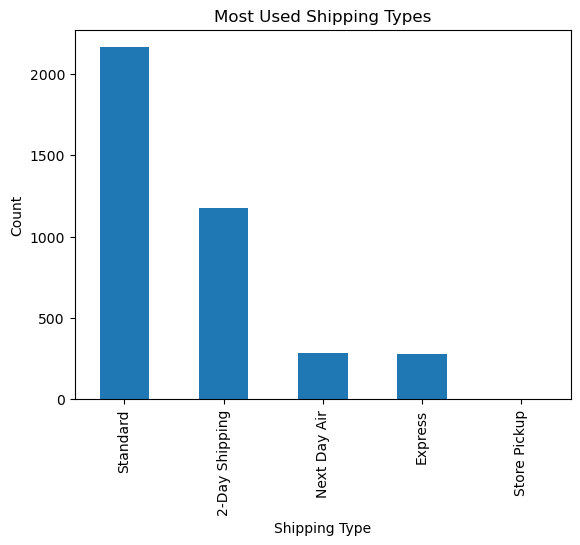

In [55]:
df['Shipping Type'].value_counts().plot(kind='bar')

plt.title("Most Used Shipping Types")
plt.xlabel("Shipping Type")
plt.ylabel("Count")
plt.show()

# Standard shipping is the most commonly used option by far, with over 2000 orders, while 2-Day Shipping is a distant second. Faster shipping options are used much less often, suggesting that most customers prioritize cost or convenience over speed.

In [44]:
# df[df['Shipping Type'] == 'Express']

# ARE REPEAT CUSTOMERS SPENDING MORE THAN FIRST-TIME OR LESS FREQUENT SHOPPERS?

In [46]:
df.groupby("Previous Purchases")["Purchase Amount (USD)"].mean()

Previous Purchases
0     38.484026
1     38.900244
2     38.889875
3     39.462363
4     38.722457
5     38.727548
6     39.307607
7     38.820971
8     38.431717
9     38.154418
10    38.450670
11    38.051063
12    39.983221
13    39.355289
14    39.353410
15    39.751774
16    33.799806
17    35.538153
18    40.897811
19    37.858389
20    37.902551
Name: Purchase Amount (USD), dtype: float64

# From the results, average spending stays relatively consistent across different levels of previous purchases, mostly ranging between about $38 and $40. There is no clear pattern showing that customers with more previous purchases spend significantly more than new or less frequent shoppers. This suggests that repeat customers are not necessarily spending more per purchase, even though they may buy more often overall.

# WHAT IS THE EFFECT OF PROMO CODES ON THE DOLLAR AMOUNT OF PURCHASES?


In [47]:
df.groupby("Promo Code Used")["Purchase Amount (USD)"].mean()

Promo Code Used
No     30.172085
Yes    50.023814
Name: Purchase Amount (USD), dtype: float64

# Customers who used promo codes spent significantly more on average, about $50.02 compared to $30.17 for those who did not use a promo code. This suggests that promo codes are effective in encouraging customers to spend more, possibly by motivating them to purchase more items or higher-value products.

# WHAT IS THE MOST POPULAR CLOTHING ITEM BY SEASON?

In [52]:
item_counts = df.groupby(["Season", "Item Purchased"]).size().reset_index(name="Count")

top_item_each_season = item_counts.loc[
    item_counts.groupby("Season")["Count"].idxmax()
]

top_item_each_season

,Season,Item Purchased,Count
14,Fall,Socks,87
20,Spring,Running Shoes,106
27,Summer,Shorts,177
35,Winter,Leggings,157


# The most popular items vary by season. In Fall, socks are the most purchased item, while running shoes are most popular in Spring. In Summer, shorts have the highest number of purchases, and in Winter, leggings are the most common. This suggests that customers tend to buy items that match seasonal needs, such as lighter clothing in warmer months and more comfortable or layered items in colder seasons.